# <center>**IROS**<center>

**Libraries**

In [1]:
import numpy as np
import mbloodmoon.iros_management as iros
import mbloodmoon as bm

In [ ]:
root_path = "/mnt/d/PhD_AASS/Coding/Images_fits/"
simul_data = root_path + "iros_simulation_GC_LMC/20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb/"

cam_a = "cam1a"
cam_b = "cam1b"
dataset = "reconstructed"

filepaths = bm.simulation_files(simul_data)
#sdlA = bm.simulation(filepaths[cam_a][dataset])
#sdlB = bm.simulation(filepaths[cam_b][dataset])

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])


N_TEST = "6_NORMALMASK"

In [3]:
database_name = root_path + f"IROS_sources_database_TEST{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


- Scatter plot with RA and DEC residues

# Checking CAM1A...
# Checking CAM1B...


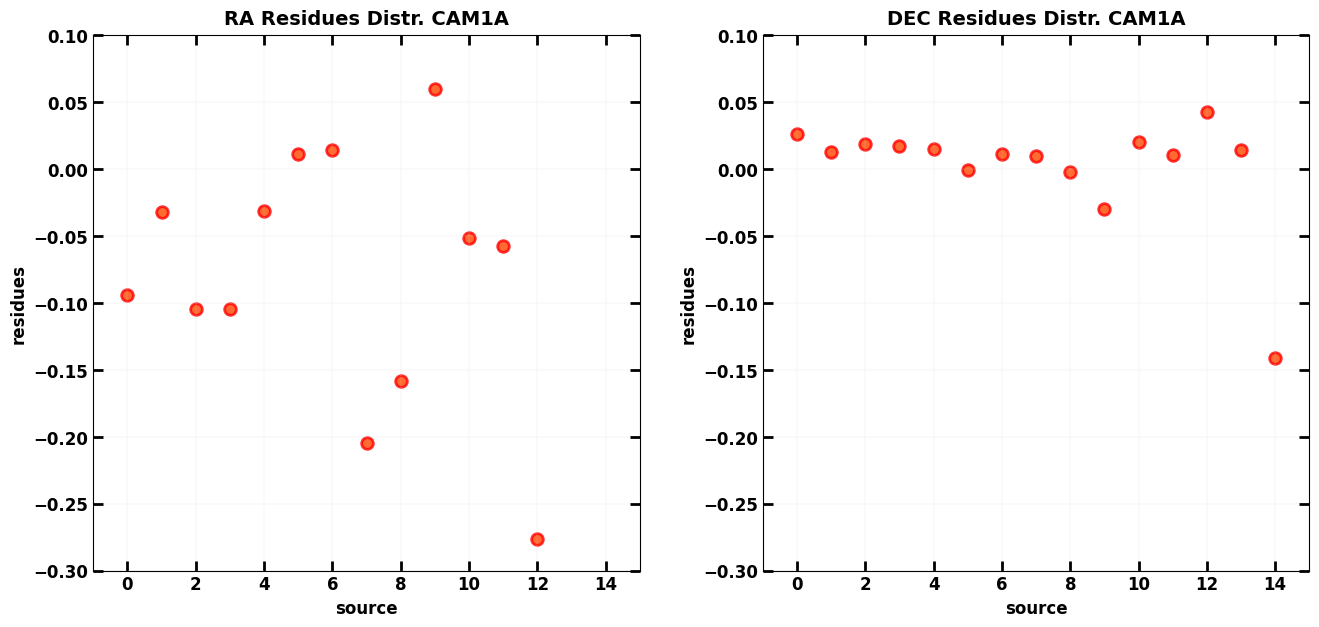

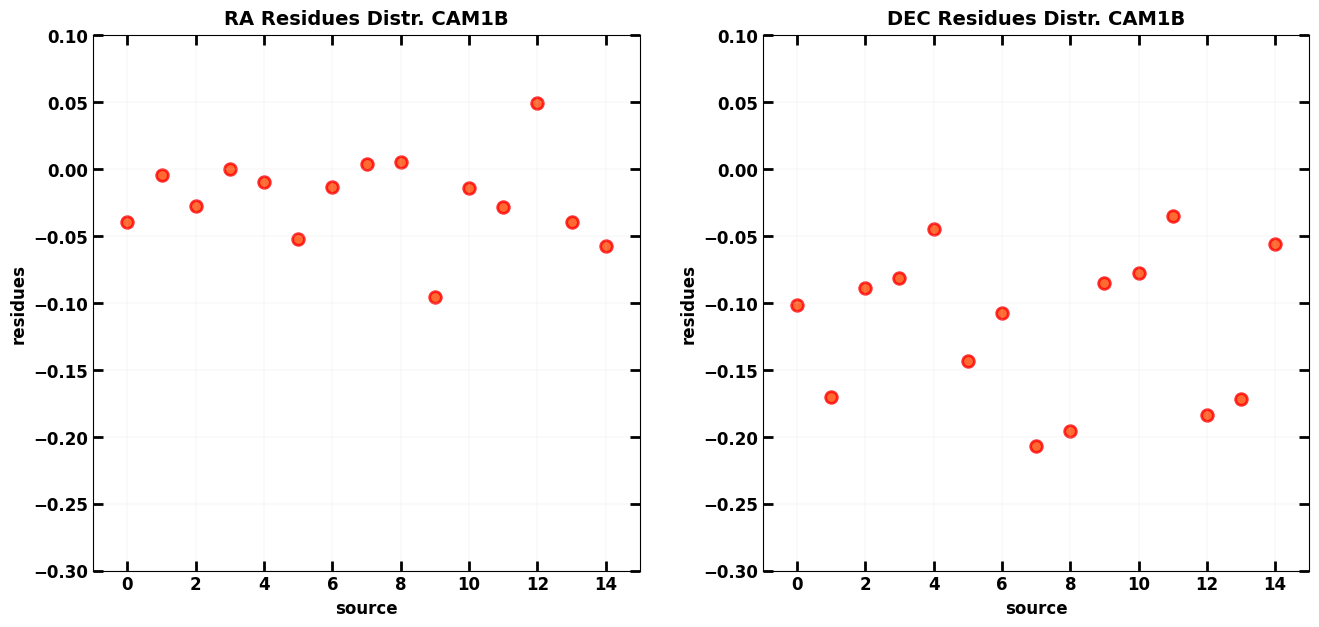

In [4]:
res_df = iros.check_sources_res(database, (catalogA, catalogB))

for cameraID in (cam_a, cam_b):
    iros.plot_sequence(
        input_sequence=[res_df[cameraID]["ra_res"], res_df[cameraID]["dec_res"]],
        title=[e + f" Residues Distr. {cameraID.upper()}" for e in ["RA", "DEC"]],
        xlabel=["source"]*2,
        ylabel=["residues"]*2,
        style=["scatter"]*2,
        offsetx=[(-1, len(res_df[cameraID]["ra_res"]))]*2,
        offsety=[(-0.3, 0.1)]*2,
    )

- Scatter plot with RA residues vs off-axis angle $\theta_{y}$, DEC residues vs off-axis angle $\theta_{x}$

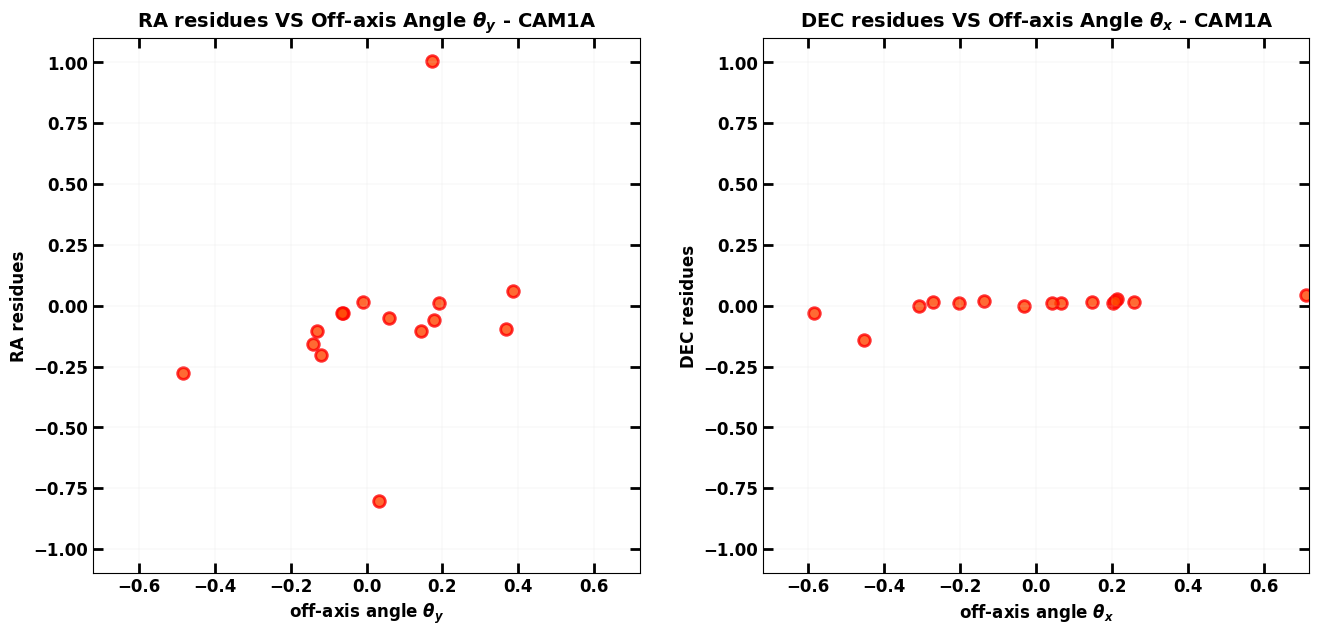

In [5]:
# CAM 1A
ra_res_cam1a = res_df[cam_a]["ra_res"]
thetay_cam1a = database[cam_a]["theta_y"]["data"]

dec_res_cam1a = res_df[cam_a]["dec_res"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

iros.plot_sequence(
    input_sequence=[ra_res_cam1a, dec_res_cam1a],
    title=[r"RA residues VS Off-axis Angle $\theta_{y}$ - CAM1A", r"DEC residues VS Off-axis Angle $\theta_{x}$ - CAM1A"],
    x=[thetay_cam1a, thetax_cam1a],
    xlabel=[r"off-axis angle $\theta_{y}$", r"off-axis angle $\theta_{x}$"],
    ylabel=["RA residues", "DEC residues"],
    style=["scatter"]*2,
    offsetx=[(-0.72, 0.72)]*2,
    offsety=[(-1.1, 1.1)]*2,
)

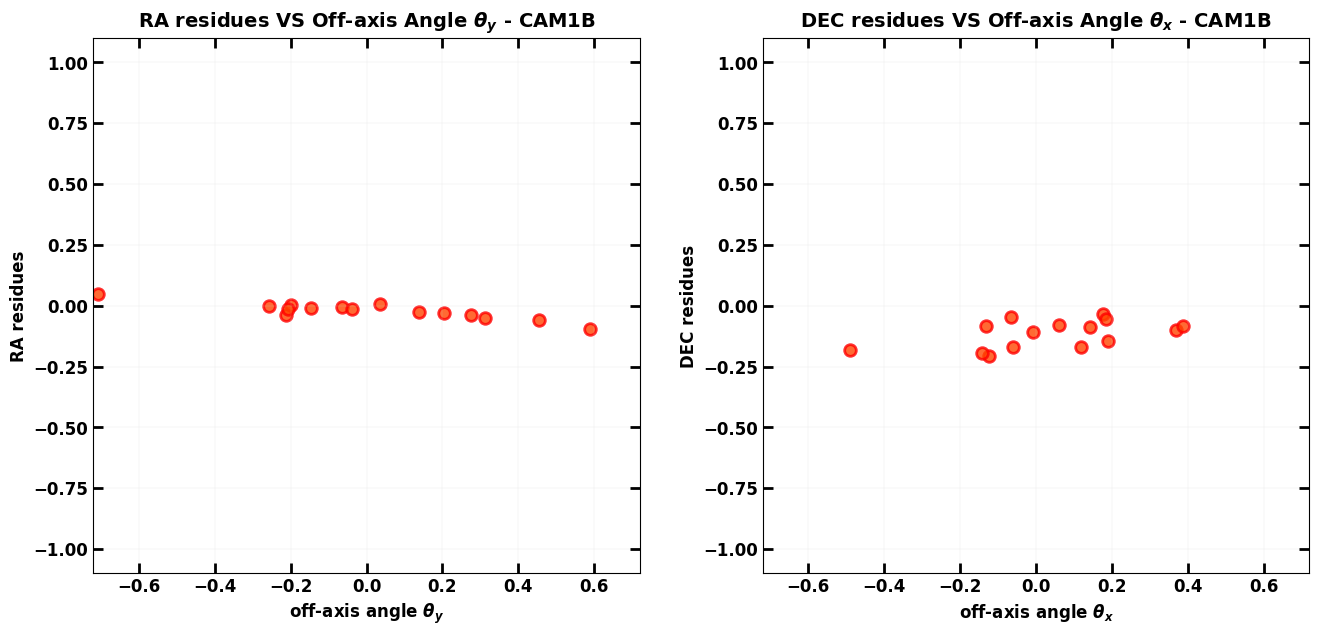

In [6]:
# CAM 1B
ra_res_cam1b = res_df[cam_b]["ra_res"]
thetay_cam1b = database[cam_b]["theta_y"]["data"]

dec_res_cam1b = res_df[cam_b]["dec_res"]
thetax_cam1b = database[cam_b]["theta_x"]["data"]

iros.plot_sequence(
    input_sequence=[ra_res_cam1b, dec_res_cam1b],
    title=[r"RA residues VS Off-axis Angle $\theta_{y}$ - CAM1B", r"DEC residues VS Off-axis Angle $\theta_{x}$ - CAM1B"],
    x=[thetay_cam1b, thetax_cam1b],
    xlabel=[r"off-axis angle $\theta_{y}$", r"off-axis angle $\theta_{x}$"],
    ylabel=["RA residues", "DEC residues"],
    style=["scatter"]*2,
    offsetx=[(-0.72, 0.72)]*2,
    offsety=[(-1.1, 1.1)]*2,
)

- Histogram with RA/DEC residues between IROS and catalog sources

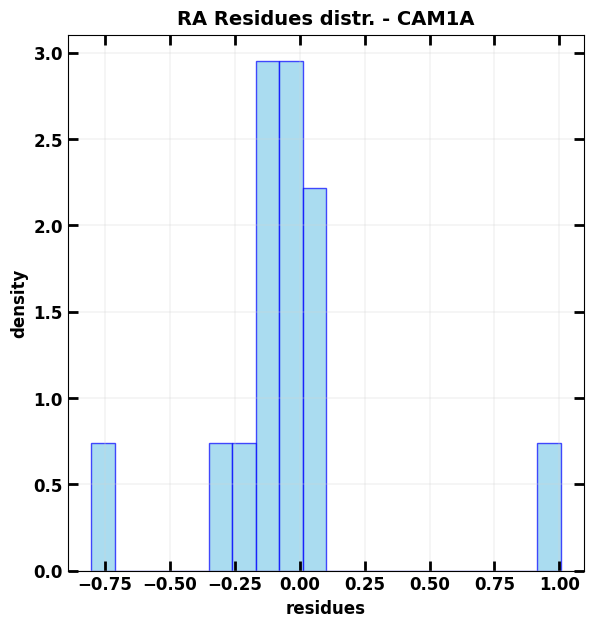

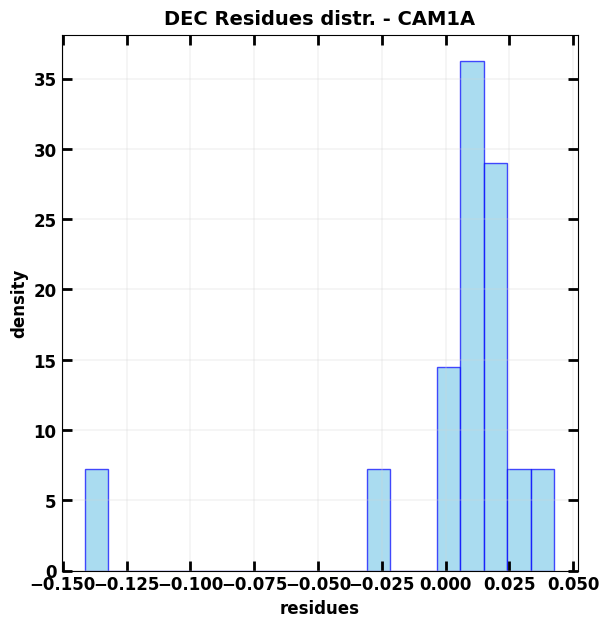

In [26]:
iros.plot_distr(
    arr=ra_res_cam1a,
    title=f"RA Residues distr. - {cam_a.upper()}",
    bins=20,
    xlabel="residues",
)
iros.plot_distr(
    arr=dec_res_cam1a,
    title=f"DEC Residues distr. - {cam_a.upper()}",
    bins=20,
    xlabel="residues",
)

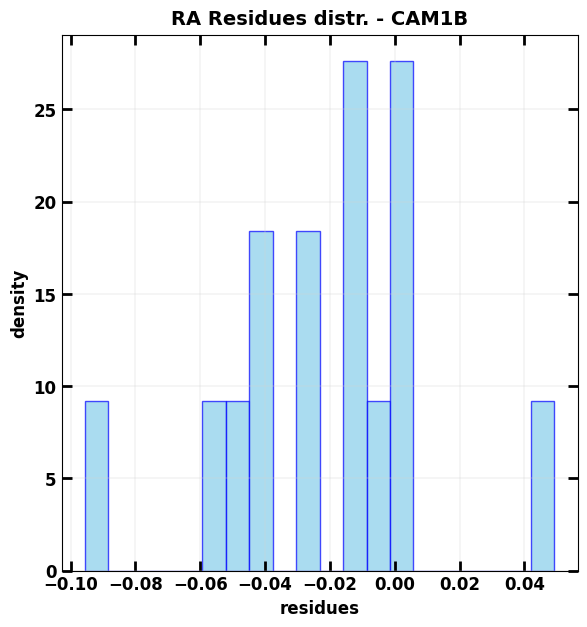

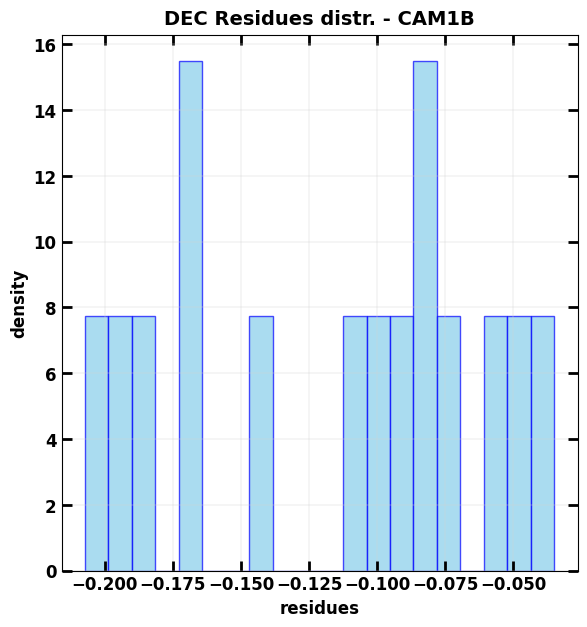

In [27]:
iros.plot_distr(
    arr=ra_res_cam1b,
    title=f"RA Residues distr. - {cam_b.upper()}",
    bins=20,
    xlabel="residues",
)
iros.plot_distr(
    arr=dec_res_cam1b,
    title=f"DEC Residues distr. - {cam_b.upper()}",
    bins=20,
    xlabel="residues",
)

- Histogram with angular separation between IROS and catalog sources

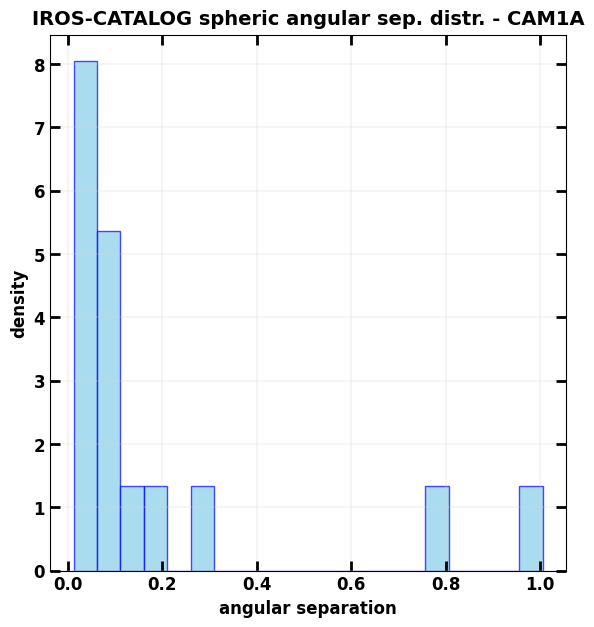

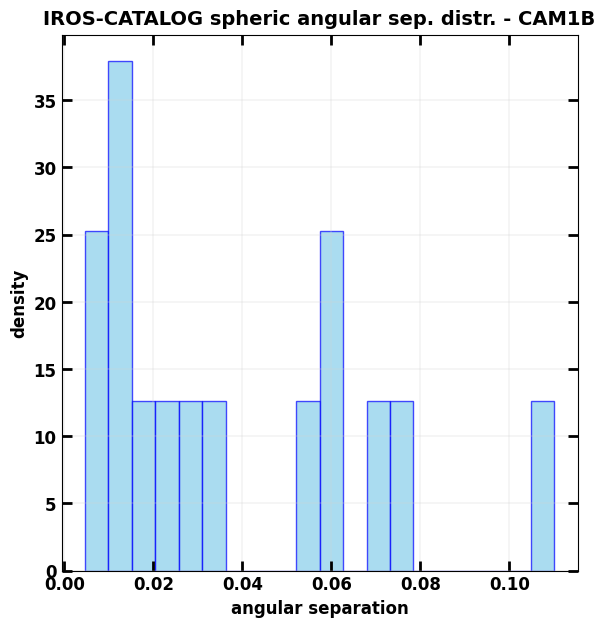

In [28]:
import astropy.units as u
from astropy.coordinates import Angle
from astropy.coordinates.angles.utils import angular_separation

ang_sep_cam1a = []
ang_sep_cam1b = []


# careful here, `angular_separation` output is in [rad]
for cam, cat, ang_sep in zip(
    (cam_a, cam_b),
    (catalogA, catalogB),
    (ang_sep_cam1a, ang_sep_cam1b),
):
    for iros_dec, iros_ra, name in zip(
        database[cam]["dec"]["data"],
        database[cam]["ra"]["data"],
        database[cam]["catalog_name"]["data"],        
    ):
        cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
        cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
        ang_sep.append(np.rad2deg(angular_separation(
            Angle(iros_dec, unit=u.deg), Angle(iros_ra, unit=u.deg),
            Angle(cat_dec, unit=u.deg), Angle(cat_ra, unit=u.deg),
        ).value))


iros.plot_distr(
    arr=np.array(ang_sep_cam1a),
    title=f"IROS-CATALOG spheric angular sep. distr. - {cam_a.upper()}",
    bins=20,
    xlabel="angular separation"
)

iros.plot_distr(
    arr=np.array(ang_sep_cam1b),
    title=f"IROS-CATALOG spheric angular sep. distr. - {cam_b.upper()}",
    bins=20,
    xlabel="angular separation"
)